# Deviation Model Comparison

This notebook compares two approaches to modeling weather effects on away team performance:

1. **Raw Model**: Predicts raw outcomes (e.g., `away_bat_k`, `away_runs_scored`)
2. **Deviation Model**: Predicts deviations from expected baseline (e.g., actual - expected)

## Hypothesis

Weather effects may be more detectable when predicting deviations from expected performance rather than raw outcomes, because:
- The baseline removes team strength and park effects
- Weather becomes a more direct signal rather than noise on top of large baseline variation

## Baseline Method

**Expected = Team Season Average × Park Factor**

This accounts for:
- Team batting strength (as away team)
- Park-specific effects (e.g., Coors Field boosts runs, Oracle Park suppresses home runs)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Import our modules
from models.data_prep import (
    load_all_team_data,
    compute_park_adjustment_factors,
    compute_team_season_averages,
    compute_deviation_targets,
    prepare_deviation_data,
    prepare_mixed_effects_data
)
from models.mixed_effects_model import (
    MixedEffectsModelFitter,
    fit_mixed_effects_models,
    fit_deviation_models
)
from models.evaluate import (
    compare_raw_vs_deviation,
    compare_variance_decomposition,
    bootstrap_model_comparison,
    plot_raw_vs_deviation_comparison
)

print("Imports complete.")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Imports complete.


## 1. Data Loading & Deviation Computation

In [2]:
# Load the combined dataset
df = load_all_team_data('../data')
print(f"Total games: {len(df)}")
print(f"Date range: {df['game_date'].min()} to {df['game_date'].max()}")

Loaded 23781 games from 30 team files
Date range: 2015-04-05 00:00:00 to 2025-09-28 00:00:00
Seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Total games: 23781
Date range: 2015-04-05 00:00:00 to 2025-09-28 00:00:00


### 1.1 Park Adjustment Factors

In [3]:
# Load and display park factors
park_factors = compute_park_adjustment_factors()

print(f"League avg strikeouts: {park_factors.attrs['league_avg_k']:.2f}")
print(f"League avg runs: {park_factors.attrs['league_avg_runs']:.2f}")

# Sort by runs factor to see most hitter-friendly parks
print("\nPark Factors (sorted by runs factor):")
display(park_factors.sort_values('runs_factor', ascending=False).head(10))

League avg strikeouts: 17.01
League avg runs: 8.90

Park Factors (sorted by runs factor):


,k_factor,runs_factor
home_team,,
COL,0.915932,1.268539
BOS,0.995885,1.106742
AZ,0.938272,1.086517
CIN,1.054674,1.079775
WSH,0.897707,1.043820
BAL,0.975897,1.031461
LAA,1.062316,1.031461
PHI,1.038213,1.028090
MIN,1.028807,1.023596


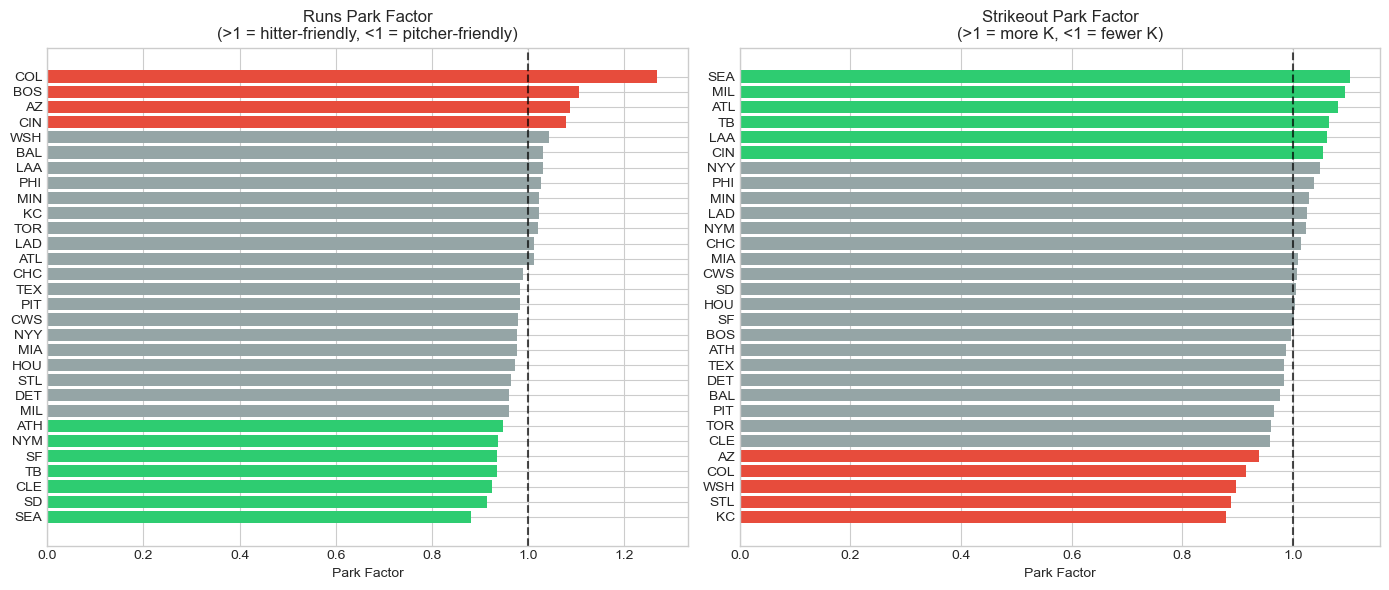

In [4]:
# Visualize park factors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Runs factor
pf_sorted = park_factors.sort_values('runs_factor', ascending=True)
colors = ['#e74c3c' if x > 1.05 else '#2ecc71' if x < 0.95 else '#95a5a6' 
          for x in pf_sorted['runs_factor']]
axes[0].barh(pf_sorted.index, pf_sorted['runs_factor'], color=colors)
axes[0].axvline(1.0, color='black', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Park Factor')
axes[0].set_title('Runs Park Factor\n(>1 = hitter-friendly, <1 = pitcher-friendly)')

# Strikeout factor
pf_sorted = park_factors.sort_values('k_factor', ascending=True)
colors = ['#e74c3c' if x < 0.95 else '#2ecc71' if x > 1.05 else '#95a5a6' 
          for x in pf_sorted['k_factor']]
axes[1].barh(pf_sorted.index, pf_sorted['k_factor'], color=colors)
axes[1].axvline(1.0, color='black', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Park Factor')
axes[1].set_title('Strikeout Park Factor\n(>1 = more K, <1 = fewer K)')

plt.tight_layout()
plt.show()

### 1.2 Compute Deviation Targets

In [5]:
# Compute deviations using leave-one-out method
df_with_dev = compute_deviation_targets(df, method='loo', min_games=10)

# Summary statistics
valid_dev = df_with_dev['deviation_away_k'].notna()
print(f"Valid deviations: {valid_dev.sum()} / {len(df_with_dev)} ({valid_dev.mean()*100:.1f}%)")

print("\nDeviation Statistics:")
for col in ['deviation_away_k', 'deviation_away_runs']:
    dev = df_with_dev[col].dropna()
    print(f"  {col}:")
    print(f"    Mean: {dev.mean():.3f} (should be ~0)")
    print(f"    Std:  {dev.std():.3f}")
    print(f"    Min:  {dev.min():.3f}, Max: {dev.max():.3f}")

Valid deviations: 23411 / 23781 (98.4%)

Deviation Statistics:
  deviation_away_k:
    Mean: 0.074 (should be ~0)
    Std:  3.061
    Min:  -9.677, Max: 18.776
  deviation_away_runs:
    Mean: 0.001 (should be ~0)
    Std:  3.267
    Min:  -7.727, Max: 21.187


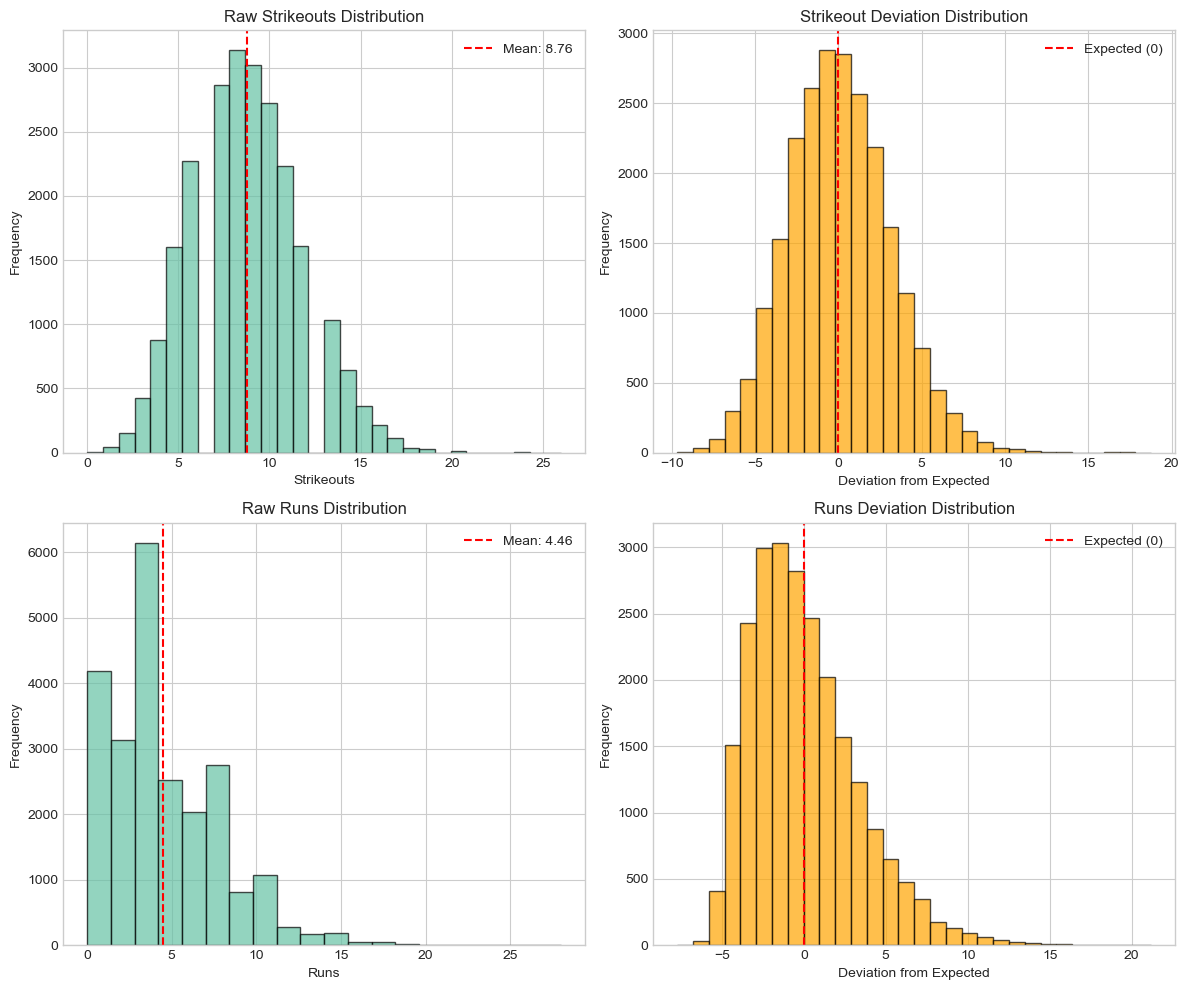

In [6]:
# Visualize deviation distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Raw vs deviation distributions for strikeouts
df_valid = df_with_dev.dropna(subset=['deviation_away_k'])

axes[0, 0].hist(df_valid['away_bat_k'], bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df_valid['away_bat_k'].mean(), color='red', linestyle='--', label=f"Mean: {df_valid['away_bat_k'].mean():.2f}")
axes[0, 0].set_xlabel('Strikeouts')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Raw Strikeouts Distribution')
axes[0, 0].legend()

axes[0, 1].hist(df_valid['deviation_away_k'], bins=30, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].axvline(0, color='red', linestyle='--', label='Expected (0)')
axes[0, 1].set_xlabel('Deviation from Expected')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Strikeout Deviation Distribution')
axes[0, 1].legend()

# Raw vs deviation distributions for runs
axes[1, 0].hist(df_valid['away_runs_scored'], bins=20, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df_valid['away_runs_scored'].mean(), color='red', linestyle='--', label=f"Mean: {df_valid['away_runs_scored'].mean():.2f}")
axes[1, 0].set_xlabel('Runs')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Raw Runs Distribution')
axes[1, 0].legend()

axes[1, 1].hist(df_valid['deviation_away_runs'], bins=30, alpha=0.7, edgecolor='black', color='orange')
axes[1, 1].axvline(0, color='red', linestyle='--', label='Expected (0)')
axes[1, 1].set_xlabel('Deviation from Expected')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Runs Deviation Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 2. Train Both Model Types

In [7]:
# Prepare data for both model types
# Use deviation data which includes both raw and deviation targets
dev_data = prepare_deviation_data(
    df, 
    standardize_weather=True,
    test_start_season=2023,
    use_enhanced_features=False,
    deviation_method='loo',
    min_games=10
)


Mixed-Effects Data Prepared:
  Training samples: 16375
  Test samples: 7091
  Home teams (parks): 30
  Away teams: 30
  Seasons: 11
  Weather standardized: True
  Enhanced features: False
  Weather features used: ['temp_f', 'rhum', 'wspd_mph', 'wind_cf', 'wind_lcf', 'wind_rcf']

Deviation Data Summary:
  Method: loo
  Min games for average: 10
  Valid deviations (train): 16251 / 16375
  Valid deviations (test): 7032 / 7091

  Deviation Stats (train):
    K deviation: mean=0.032, std=3.074
    Runs deviation: mean=-0.012, std=3.262


In [8]:
# Fit RAW target models
print("="*60)
print("FITTING RAW TARGET MODELS")
print("="*60)

k_raw_fitter, runs_raw_fitter = fit_mixed_effects_models(dev_data)

FITTING RAW TARGET MODELS

Fitting models with:
  Weather features: ['temp_f', 'rhum', 'wspd_mph', 'wind_cf', 'wind_lcf', 'wind_rcf']
  Random slope features: ['temp_f', 'wspd_mph']

Fitting Mixed-Effects Models for away_bat_k

[1/4] Fitting null model (team + season random effects)...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


      Converged: True

[2/4] Fitting fixed weather effects model...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


      Converged: True

[3/4] Fitting park random intercept model...


...

      Converged: True

[3/4] Fitting park random intercept model...


      Converged: True

[4/4] Fitting park random slopes model...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 286.172398
  warnings.warn(msg, ConvergenceWarning)


      Converged: False


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [9]:
# Fit DEVIATION target models
print("="*60)
print("FITTING DEVIATION TARGET MODELS")
print("="*60)

k_dev_fitter, runs_dev_fitter = fit_deviation_models(dev_data)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


FITTING DEVIATION TARGET MODELS

Fitting DEVIATION models with:
  Weather features: ['temp_f', 'rhum', 'wspd_mph', 'wind_cf', 'wind_lcf', 'wind_rcf']
  Random slope features: ['temp_f', 'wspd_mph']
  Target type: deviation
  Training samples (with valid deviations): 16251

Fitting Mixed-Effects Models for deviation_away_k

[1/4] Fitting null model (team + season random effects)...


      Converged: True

[2/4] Fitting fixed weather effects model...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


      Converged: True

[3/4] Fitting park random intercept model...


...

      Converged: True

Fitting Mixed-Effects Models for deviation_away_runs

[1/4] Fitting null model (team + season random effects)...
      Converged: True

[2/4] Fitting fixed weather effects model...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


      Converged: True

[3/4] Fitting park random intercept model...


      Converged: True

[4/4] Fitting park random slopes model...


      Converged: True


## 3. Compare Models on Test Set

In [10]:
# Compare strikeouts models
k_comparison = compare_raw_vs_deviation(
    k_raw_fitter, 
    k_dev_fitter, 
    dev_data['df_test'],
    target_name='Strikeouts'
)

print("STRIKEOUTS MODEL COMPARISON (on raw scale)")
print("="*60)
print("\nRaw Model:")
for model, metrics in k_comparison['raw_model'].items():
    if 'error' not in metrics:
        print(f"  {model}: RMSE={metrics['RMSE']:.3f}, R²={metrics['R2']:.4f}")

print("\nDeviation Model (evaluated on raw scale):")
for model, metrics in k_comparison['deviation_model'].items():
    if 'error' not in metrics:
        print(f"  {model}: RMSE={metrics['RMSE']:.3f}, R²={metrics['R2']:.4f}")

if k_comparison['improvement']:
    imp = k_comparison['improvement']
    print(f"\nImprovement ({imp['model']}): {imp['pct_improvement']:.2f}%")
    print(f"  Raw RMSE: {imp['raw_rmse']:.3f}")
    print(f"  Dev RMSE: {imp['dev_rmse']:.3f}")

STRIKEOUTS MODEL COMPARISON (on raw scale)

Raw Model:
  park_intercept: RMSE=2.964, R²=-0.0051
  park_slopes: RMSE=2.964, R²=-0.0046
  fixed_weather: RMSE=2.957, R²=0.0001

Deviation Model (evaluated on raw scale):
  park_intercept: RMSE=3.039, R²=-0.0564
  park_slopes: RMSE=3.040, R²=-0.0570
  fixed_weather: RMSE=3.035, R²=-0.0534

Improvement (park_slopes): -2.57%
  Raw RMSE: 2.964
  Dev RMSE: 3.040


In [11]:
# Compare runs models
runs_comparison = compare_raw_vs_deviation(
    runs_raw_fitter, 
    runs_dev_fitter, 
    dev_data['df_test'],
    target_name='Runs'
)

print("RUNS MODEL COMPARISON (on raw scale)")
print("="*60)
print("\nRaw Model:")
for model, metrics in runs_comparison['raw_model'].items():
    if 'error' not in metrics:
        print(f"  {model}: RMSE={metrics['RMSE']:.3f}, R²={metrics['R2']:.4f}")

print("\nDeviation Model (evaluated on raw scale):")
for model, metrics in runs_comparison['deviation_model'].items():
    if 'error' not in metrics:
        print(f"  {model}: RMSE={metrics['RMSE']:.3f}, R²={metrics['R2']:.4f}")

if runs_comparison['improvement']:
    imp = runs_comparison['improvement']
    print(f"\nImprovement ({imp['model']}): {imp['pct_improvement']:.2f}%")
    print(f"  Raw RMSE: {imp['raw_rmse']:.3f}")
    print(f"  Dev RMSE: {imp['dev_rmse']:.3f}")

RUNS MODEL COMPARISON (on raw scale)

Raw Model:
  park_intercept: RMSE=3.265, R²=0.0047
  park_slopes: RMSE=3.264, R²=0.0054
  fixed_weather: RMSE=3.264, R²=0.0053

Deviation Model (evaluated on raw scale):
  park_intercept: RMSE=3.285, R²=-0.0075
  park_slopes: RMSE=3.284, R²=-0.0069
  fixed_weather: RMSE=3.283, R²=-0.0059

Improvement (park_slopes): -0.61%
  Raw RMSE: 3.264
  Dev RMSE: 3.284


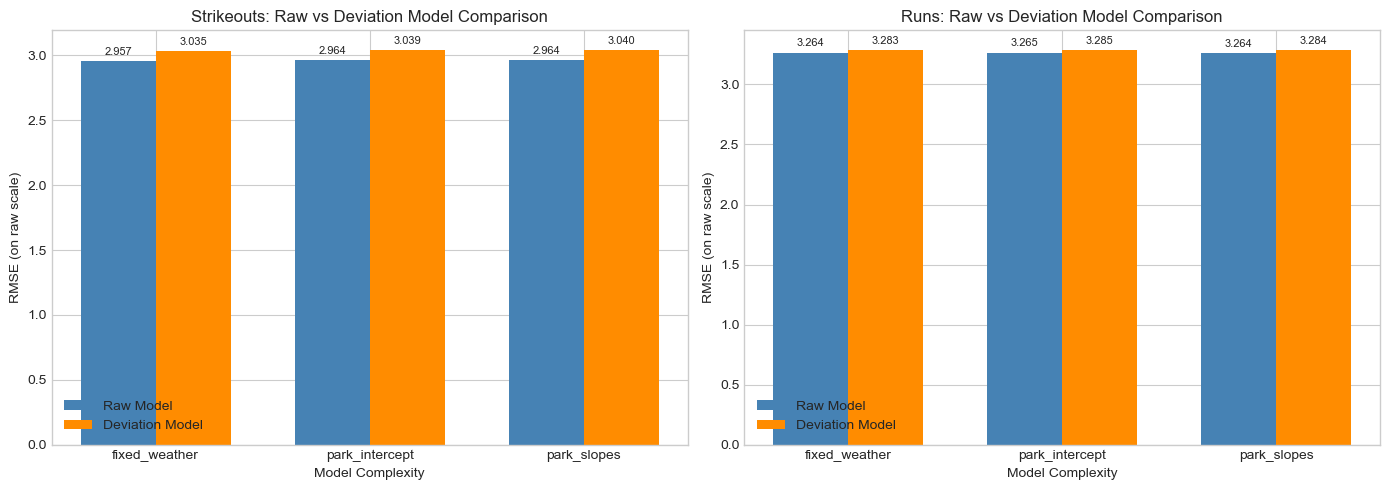

In [12]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_raw_vs_deviation_comparison(k_comparison, 'Strikeouts', axes[0])
plot_raw_vs_deviation_comparison(runs_comparison, 'Runs', axes[1])

plt.tight_layout()
plt.show()

## 4. Weather Coefficient Comparison

In [13]:
# Compare weather coefficients for strikeouts
print("STRIKEOUTS: Weather Coefficient Comparison")
print("="*60)
if k_comparison['weather_coef_comparison'] is not None:
    coef_df = k_comparison['weather_coef_comparison']
    # Filter to weather features only
    weather_params = coef_df[coef_df['Parameter'].isin(['temp_f', 'rhum', 'wspd_mph', 'wind_cf', 'is_night'])]
    display(weather_params)
else:
    print(f"Error: {k_comparison.get('coef_error', 'Unknown')}")

STRIKEOUTS: Weather Coefficient Comparison


,Parameter,Raw_Coef,Raw_SE,Raw_p,Dev_Coef,Dev_SE,Dev_p
1,is_night,-0.213091,0.052523,0.000050,-0.190207,0.054976,0.000541
2,rhum,-0.124200,0.030795,0.000055,-0.139206,0.032822,0.000022
3,temp_f,-0.107210,0.038372,0.005207,-0.120254,0.432815,0.781134
4,wind_cf,34.548537,59.611486,0.562210,41.523023,61.794349,0.501612
7,wspd_mph,0.014704,0.037397,0.694171,-0.001403,0.431100,0.997404


In [14]:
# Compare weather coefficients for runs
print("RUNS: Weather Coefficient Comparison")
print("="*60)
if runs_comparison['weather_coef_comparison'] is not None:
    coef_df = runs_comparison['weather_coef_comparison']
    # Filter to weather features only
    weather_params = coef_df[coef_df['Parameter'].isin(['temp_f', 'rhum', 'wspd_mph', 'wind_cf', 'is_night'])]
    display(weather_params)
else:
    print(f"Error: {runs_comparison.get('coef_error', 'Unknown')}")

RUNS: Weather Coefficient Comparison


,Parameter,Raw_Coef,Raw_SE,Raw_p,Dev_Coef,Dev_SE,Dev_p
1,is_night,0.208757,0.058622,0.000369,0.203638,0.059587,0.000632
2,rhum,-0.113698,0.034062,0.000844,-0.073722,0.034915,0.034731
3,temp_f,0.140335,0.119385,0.239802,0.201213,0.066141,0.002349
4,wind_cf,8.227547,66.562592,0.901627,-23.673055,67.817905,0.727038
7,wspd_mph,0.042616,0.123616,0.730286,0.072097,0.037093,0.051935


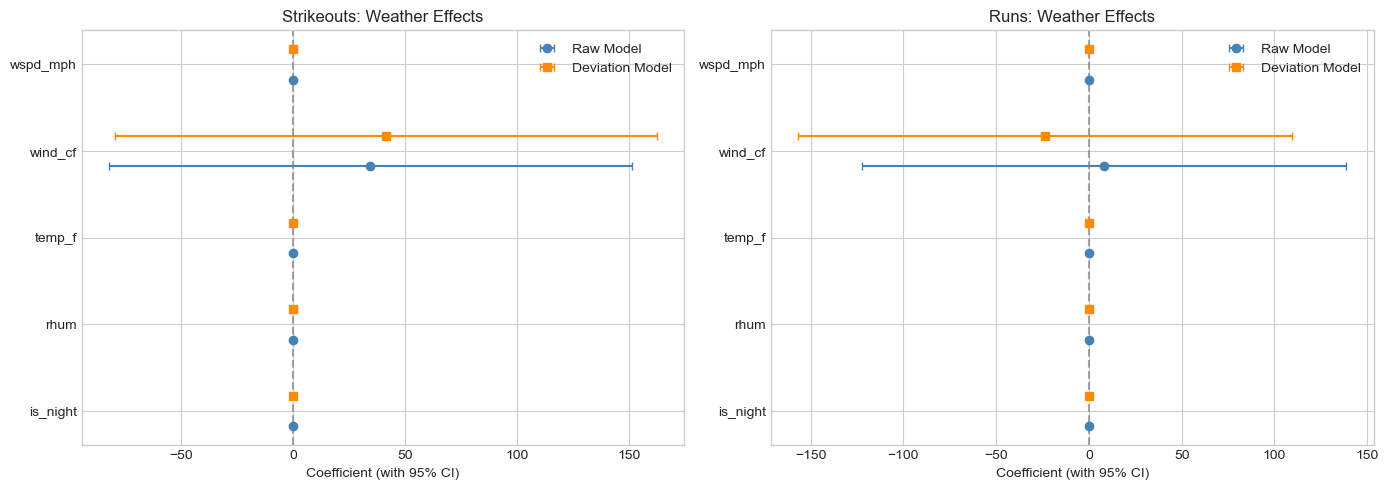

In [15]:
# Visualize coefficient comparison as a forest plot
def plot_coefficient_comparison(coef_df, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Filter to weather features
    weather_params = ['temp_f', 'rhum', 'wspd_mph', 'wind_cf', 'is_night']
    df = coef_df[coef_df['Parameter'].isin(weather_params)].copy()
    
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No weather coefficients found', ha='center', va='center')
        return ax
    
    y = np.arange(len(df))
    height = 0.35
    
    # Raw model
    raw_coef = df['Raw_Coef'].fillna(0)
    raw_se = df['Raw_SE'].fillna(0)
    ax.errorbar(raw_coef, y - height/2, xerr=1.96*raw_se, fmt='o', 
                color='steelblue', label='Raw Model', capsize=3)
    
    # Deviation model
    dev_coef = df['Dev_Coef'].fillna(0)
    dev_se = df['Dev_SE'].fillna(0)
    ax.errorbar(dev_coef, y + height/2, xerr=1.96*dev_se, fmt='s',
                color='darkorange', label='Deviation Model', capsize=3)
    
    ax.axvline(0, color='gray', linestyle='--', alpha=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(df['Parameter'])
    ax.set_xlabel('Coefficient (with 95% CI)')
    ax.set_title(title)
    ax.legend()
    
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if k_comparison['weather_coef_comparison'] is not None:
    plot_coefficient_comparison(k_comparison['weather_coef_comparison'], 
                                'Strikeouts: Weather Effects', axes[0])
if runs_comparison['weather_coef_comparison'] is not None:
    plot_coefficient_comparison(runs_comparison['weather_coef_comparison'],
                                'Runs: Weather Effects', axes[1])

plt.tight_layout()
plt.show()

## 5. Variance Decomposition Comparison

In [16]:
# Compare variance decomposition
print("STRIKEOUTS: Variance Decomposition Comparison")
print("="*60)
k_var = compare_variance_decomposition(k_raw_fitter, k_dev_fitter, 'park_intercept')
if k_var is not None:
    display(k_var)

STRIKEOUTS: Variance Decomposition Comparison


,Source,Type,Raw_Variance,Raw_Pct,Dev_Variance,Dev_Pct
0,Group (home_team),Random Intercept,0.447447,5.07,5.910624,38.76
1,Residual,Residual,7.883109,89.31,8.353462,54.78
2,VC_0,Variance Component,0.132653,1.50,0.173332,1.14
3,VC_1,Variance Component,0.363193,4.11,0.811645,5.32


In [17]:
print("RUNS: Variance Decomposition Comparison")
print("="*60)
runs_var = compare_variance_decomposition(runs_raw_fitter, runs_dev_fitter, 'park_intercept')
if runs_var is not None:
    display(runs_var)

RUNS: Variance Decomposition Comparison


,Source,Type,Raw_Variance,Raw_Pct,Dev_Variance,Dev_Pct
0,Group (home_team),Random Intercept,0.205169,1.98,0.136744,1.29
1,Residual,Residual,9.880236,95.41,10.161260,95.74
2,VC_0,Variance Component,0.089589,0.87,0.084640,0.80
3,VC_1,Variance Component,0.180856,1.75,0.230234,2.17


## 6. Bootstrap Statistical Test

In [18]:
# Bootstrap comparison for strikeouts
print("Bootstrap RMSE Comparison (Strikeouts)")
print("="*60)

try:
    k_bootstrap = bootstrap_model_comparison(
        k_raw_fitter, k_dev_fitter, 
        dev_data['df_test'],
        model_name='park_intercept',
        n_bootstrap=500
    )
    print(f"RMSE difference (Raw - Dev): {k_bootstrap['rmse_diff']:.4f}")
    print(f"95% CI: [{k_bootstrap['ci_lower']:.4f}, {k_bootstrap['ci_upper']:.4f}]")
    print(f"Statistically significant: {k_bootstrap['significant']}")
    if k_bootstrap['rmse_diff'] > 0:
        print("-> Deviation model has lower RMSE (better)")
    else:
        print("-> Raw model has lower RMSE (better)")
except Exception as e:
    print(f"Error: {e}")

Bootstrap RMSE Comparison (Strikeouts)
Error: '[3204, 5387, 4602, 3201, 3810, 1612, 3815, 3200, 3202, 6190, 6961, 4603, 4605, 6962, 3814, 843, 6963, 2392, 845, 844, 847, 41, 5389, 4606, 1609, 1608, 2390, 3809, 846, 5388, 39, 3811, 4604, 6960, 6957, 38, 37] not in index'


In [19]:
# Bootstrap comparison for runs
print("Bootstrap RMSE Comparison (Runs)")
print("="*60)

try:
    runs_bootstrap = bootstrap_model_comparison(
        runs_raw_fitter, runs_dev_fitter,
        dev_data['df_test'],
        model_name='park_intercept',
        n_bootstrap=500
    )
    print(f"RMSE difference (Raw - Dev): {runs_bootstrap['rmse_diff']:.4f}")
    print(f"95% CI: [{runs_bootstrap['ci_lower']:.4f}, {runs_bootstrap['ci_upper']:.4f}]")
    print(f"Statistically significant: {runs_bootstrap['significant']}")
    if runs_bootstrap['rmse_diff'] > 0:
        print("-> Deviation model has lower RMSE (better)")
    else:
        print("-> Raw model has lower RMSE (better)")
except Exception as e:
    print(f"Error: {e}")

Bootstrap RMSE Comparison (Runs)


RMSE difference (Raw - Dev): -0.0200
95% CI: [-0.0341, -0.0063]
Statistically significant: True
-> Raw model has lower RMSE (better)


## 7. Predicted vs Actual Plots

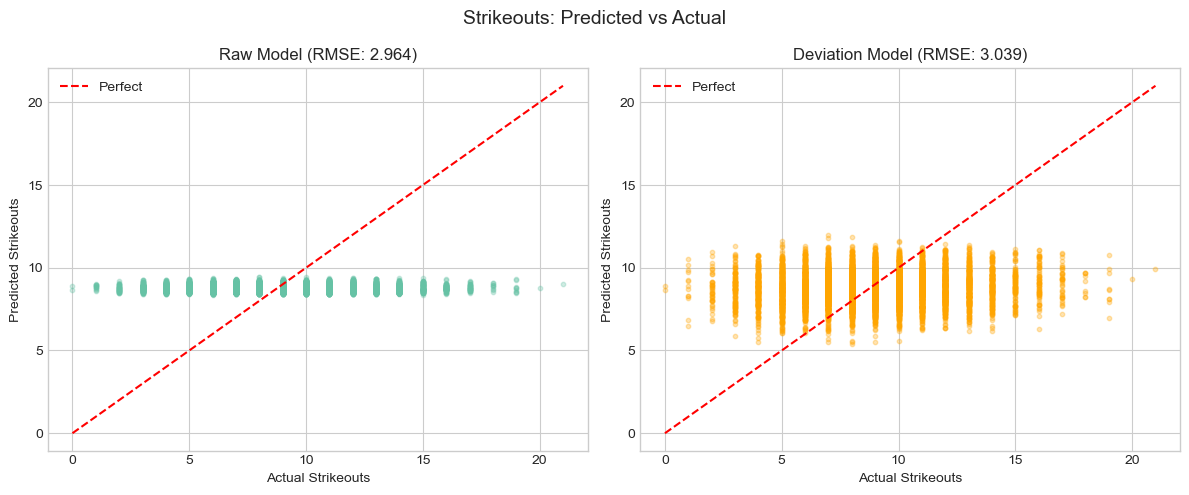

In [20]:
# Prepare test data with valid deviations
df_test_valid = dev_data['df_test'].dropna(subset=['deviation_away_k', 'expected_away_k']).copy()

# Get predictions for strikeouts
y_true_k = df_test_valid['away_bat_k'].values
try:
    y_pred_raw_k = k_raw_fitter.predict(df_test_valid, 'park_intercept')
    y_pred_dev_k = k_dev_fitter.predict_raw(df_test_valid, 'park_intercept')
except:
    y_pred_raw_k = k_raw_fitter.predict(df_test_valid, 'fixed_weather')
    y_pred_dev_k = k_dev_fitter.predict_raw(df_test_valid, 'fixed_weather')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw model
axes[0].scatter(y_true_k, y_pred_raw_k, alpha=0.3, s=10)
min_val = min(y_true_k.min(), y_pred_raw_k.min())
max_val = max(y_true_k.max(), y_pred_raw_k.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect')
rmse = np.sqrt(np.mean((y_true_k - y_pred_raw_k)**2))
axes[0].set_xlabel('Actual Strikeouts')
axes[0].set_ylabel('Predicted Strikeouts')
axes[0].set_title(f'Raw Model (RMSE: {rmse:.3f})')
axes[0].legend()

# Deviation model
axes[1].scatter(y_true_k, y_pred_dev_k, alpha=0.3, s=10, color='orange')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect')
rmse = np.sqrt(np.mean((y_true_k - y_pred_dev_k)**2))
axes[1].set_xlabel('Actual Strikeouts')
axes[1].set_ylabel('Predicted Strikeouts')
axes[1].set_title(f'Deviation Model (RMSE: {rmse:.3f})')
axes[1].legend()

plt.suptitle('Strikeouts: Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Summary & Conclusions

In [21]:
print("="*70)
print("SUMMARY: RAW vs DEVIATION MODEL COMPARISON")
print("="*70)

print("\n--- STRIKEOUTS ---")
if k_comparison['improvement']:
    imp = k_comparison['improvement']
    if imp['pct_improvement'] > 0:
        print(f"Deviation model BETTER by {imp['pct_improvement']:.2f}%")
    else:
        print(f"Raw model BETTER by {-imp['pct_improvement']:.2f}%")
    print(f"  Raw RMSE:       {imp['raw_rmse']:.3f}")
    print(f"  Deviation RMSE: {imp['dev_rmse']:.3f}")

print("\n--- RUNS ---")
if runs_comparison['improvement']:
    imp = runs_comparison['improvement']
    if imp['pct_improvement'] > 0:
        print(f"Deviation model BETTER by {imp['pct_improvement']:.2f}%")
    else:
        print(f"Raw model BETTER by {-imp['pct_improvement']:.2f}%")
    print(f"  Raw RMSE:       {imp['raw_rmse']:.3f}")
    print(f"  Deviation RMSE: {imp['dev_rmse']:.3f}")

print("\n--- INTERPRETATION ---")
print("""
If the deviation model performs BETTER:
- Weather effects are more detectable after removing baseline variation
- The team/park baseline was adding noise to weather signal
- Recommendation: Use deviation model for weather analysis

If the deviation model performs SIMILARLY:
- Mixed effects were already handling baselines effectively
- Deviation approach adds complexity without benefit
- Recommendation: Stick with simpler raw model

If the deviation model performs WORSE:
- Information loss from averaging process
- Early-season sparsity issues
- Non-linear effects not captured by simple park factors
- Recommendation: Use raw model
""")

SUMMARY: RAW vs DEVIATION MODEL COMPARISON

--- STRIKEOUTS ---
Raw model BETTER by 2.57%
  Raw RMSE:       2.964
  Deviation RMSE: 3.040

--- RUNS ---
Raw model BETTER by 0.61%
  Raw RMSE:       3.264
  Deviation RMSE: 3.284

--- INTERPRETATION ---

If the deviation model performs BETTER:
- Weather effects are more detectable after removing baseline variation
- The team/park baseline was adding noise to weather signal
- Recommendation: Use deviation model for weather analysis

If the deviation model performs SIMILARLY:
- Mixed effects were already handling baselines effectively
- Deviation approach adds complexity without benefit
- Recommendation: Stick with simpler raw model

If the deviation model performs WORSE:
- Information loss from averaging process
- Early-season sparsity issues
- Non-linear effects not captured by simple park factors
- Recommendation: Use raw model

